In [135]:
import numpy as np
from datetime import datetime
import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.config import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

In [140]:
now = datetime.now().strftime("%d%m%y_%H%M%S")
now

'250226_161813'

In [133]:
Path('model_testing_torch.ipynb').resolve().parent.parent.parent

PosixPath('/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier')

In [2]:
class LISADataset(Dataset):
    
    def __init__(self, h5_path):
        
        self.file = h5py.File(h5_path, "r")
        
        self.images = self.file["images"]
        self.labels = self.file["labels"]
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        
        image = self.images[idx]
        label = self.labels[idx]
        
        # convert to float32
        image = image.astype(np.float32)
        label = label.astype(np.float32)
        
        # convert HWC → CHW
        image = np.transpose(image, (2,0,1))
        
        # convert to torch tensor
        image = torch.from_numpy(image)
        label = torch.from_numpy(label)
        
        return image, label

In [72]:
def soft_accuracy(model, dataset, threshold=0.5):
    device = torch.device("mps")
    model.eval()
    loader = DataLoader(dataset, batch_size=1)

    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            correct += (predicted == labels).sum().item()
            total += labels.numel()
    
    model.train()
    return correct / total

def hard_accuracy(model, dataset, threshold=0.5):
    device = torch.device("mps")
    model.eval()
    loader = DataLoader(dataset, batch_size=1)

    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            correct += ((predicted == labels).all(dim=1)).sum().item()
            total += labels.size(0)
    
    model.train()
    return correct / total

In [ ]:
def train_model(model, train_data, val_data,
                learning_rate=0.005, batch_size=10,
                num_epochs=10, plot_every=10, print_every=10):
    device = torch.device("mps")
    model = model.to(device)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True) # reshuffle minibatches every epoch
    criterion = torch.nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    iters, train_loss, train_soft_acc, val_soft_acc, train_hard_acc, val_hard_acc = [], [], [], [], [], []
    iter_count = 0

    for e in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            z = model(images)
            loss = criterion(z, labels)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            iter_count += 1
            if iter_count % plot_every == 0:
                iters.append(iter_count)
                train_loss.append(float(loss))
                train_soft_acc.append(soft_accuracy(model, train_data))
                val_soft_acc.append(soft_accuracy(model, val_data))
                train_hard_acc.append(hard_accuracy(model, train_data))
                val_hard_acc.append(hard_accuracy(model, val_data))
                
            if iter_count % print_every == 0:
                print(f"Epoch {e+1}/{num_epochs}, Iteration {iter_count}, Loss: {loss:.3f}, " +\
                        f" Train Soft Acc: {train_soft_acc[-1]:.3f}, Val Soft Acc: {val_soft_acc[-1]:.3f}, " +\
                        f"Train Hard Acc: {train_hard_acc[-1]:.3f}, Val Hard Acc: {val_hard_acc[-1]:.3f}")
    
    return iters, train_loss, train_soft_acc, val_soft_acc, train_hard_acc, val_hard_acc
        

In [39]:
dataset = LISADataset(training_ehm_dataset_path)

N = len(dataset)

train_size = int(0.7 * N)
val_size   = int(0.2 * N)
test_size  = N - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size])

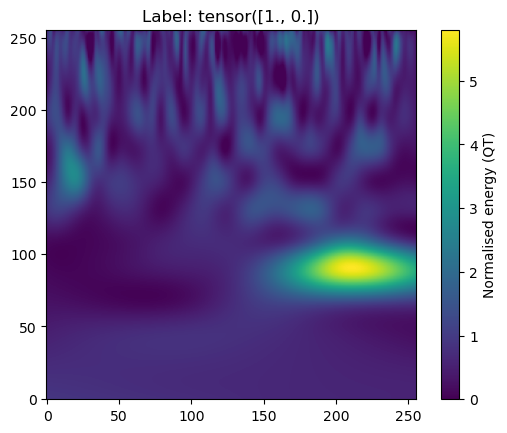

In [54]:
image, label = dataset[507]

plt.imshow(image[0], origin="lower")
plt.title(f"Label: {label}")
plt.colorbar(label='Normalised energy (QT)')
#plt.yscale("log")
plt.show()

## Model training

In [ ]:
class CNN(nn.Module):
    def __init__(self, width=4, bn=True):
        
        super(CNN, self).__init__()
        self.width = width
        self.bn = bn
        self.conv1 = nn.Conv2d(in_channels=3,
                               out_channels=self.width,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(in_channels=self.width,
                               out_channels=self.width*2,
                               kernel_size=3,
                               padding=1)
        self.conv3 = nn.Conv2d(in_channels=self.width*2,
                               out_channels=self.width*4,
                               kernel_size=3,
                               padding=1)
        self.conv4 = nn.Conv2d(in_channels=self.width*4,
                               out_channels=self.width*8,
                               kernel_size=3,
                               padding=1)
        
        if bn:
            self.bn1 = nn.BatchNorm2d(self.width)
            self.bn2 = nn.BatchNorm2d(self.width*2)
            self.bn3 = nn.BatchNorm2d(self.width*4)
            self.bn4 = nn.BatchNorm2d(self.width*8)
        
        self.pool = nn.MaxPool2d(2, 2)
       
        self.fc1 = nn.Linear(self.width * 8 * 16 * 16, 100)
        self.fc2 = nn.Linear(100, 2)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        if self.bn:
            x = self.bn1(x)
        x = self.pool(torch.relu(self.conv2(x)))
        if self.bn:
            x = self.bn2(x)
        x = self.pool(torch.relu(self.conv3(x)))
        if self.bn:
            x = self.bn3(x)
        x = self.pool(torch.relu(self.conv4(x)))
        if self.bn:
            x = self.bn4(x)
        x = x.view(-1, self.width * 8 * 16 * 16)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [77]:
model = CNN(width=8, bn=True)
batch_size = 32
learning_rate = 0.001
num_epochs = 9
results = train_model(model, train_dataset, val_dataset,
                    batch_size=batch_size, learning_rate=learning_rate, 
                    num_epochs=num_epochs, plot_every=2, print_every=15)

Epoch 1/9, Iteration 15, Loss: 0.234,  Train Soft Acc: 0.524, Val Soft Acc: 0.519, Train Hard Acc: 0.270, Val Hard Acc: 0.291
Epoch 1/9, Iteration 30, Loss: 0.166,  Train Soft Acc: 0.674, Val Soft Acc: 0.668, Train Hard Acc: 0.450, Val Hard Acc: 0.445
Epoch 2/9, Iteration 45, Loss: 0.178,  Train Soft Acc: 0.933, Val Soft Acc: 0.923, Train Hard Acc: 0.867, Val Hard Acc: 0.853
Epoch 2/9, Iteration 60, Loss: 0.080,  Train Soft Acc: 0.922, Val Soft Acc: 0.904, Train Hard Acc: 0.846, Val Hard Acc: 0.812
Epoch 3/9, Iteration 75, Loss: 0.134,  Train Soft Acc: 0.953, Val Soft Acc: 0.933, Train Hard Acc: 0.906, Val Hard Acc: 0.866
Epoch 3/9, Iteration 90, Loss: 0.082,  Train Soft Acc: 0.968, Val Soft Acc: 0.950, Train Hard Acc: 0.936, Val Hard Acc: 0.904
Epoch 4/9, Iteration 105, Loss: 0.086,  Train Soft Acc: 0.969, Val Soft Acc: 0.937, Train Hard Acc: 0.937, Val Hard Acc: 0.873
Epoch 4/9, Iteration 120, Loss: 0.024,  Train Soft Acc: 0.957, Val Soft Acc: 0.949, Train Hard Acc: 0.915, Val Hard A

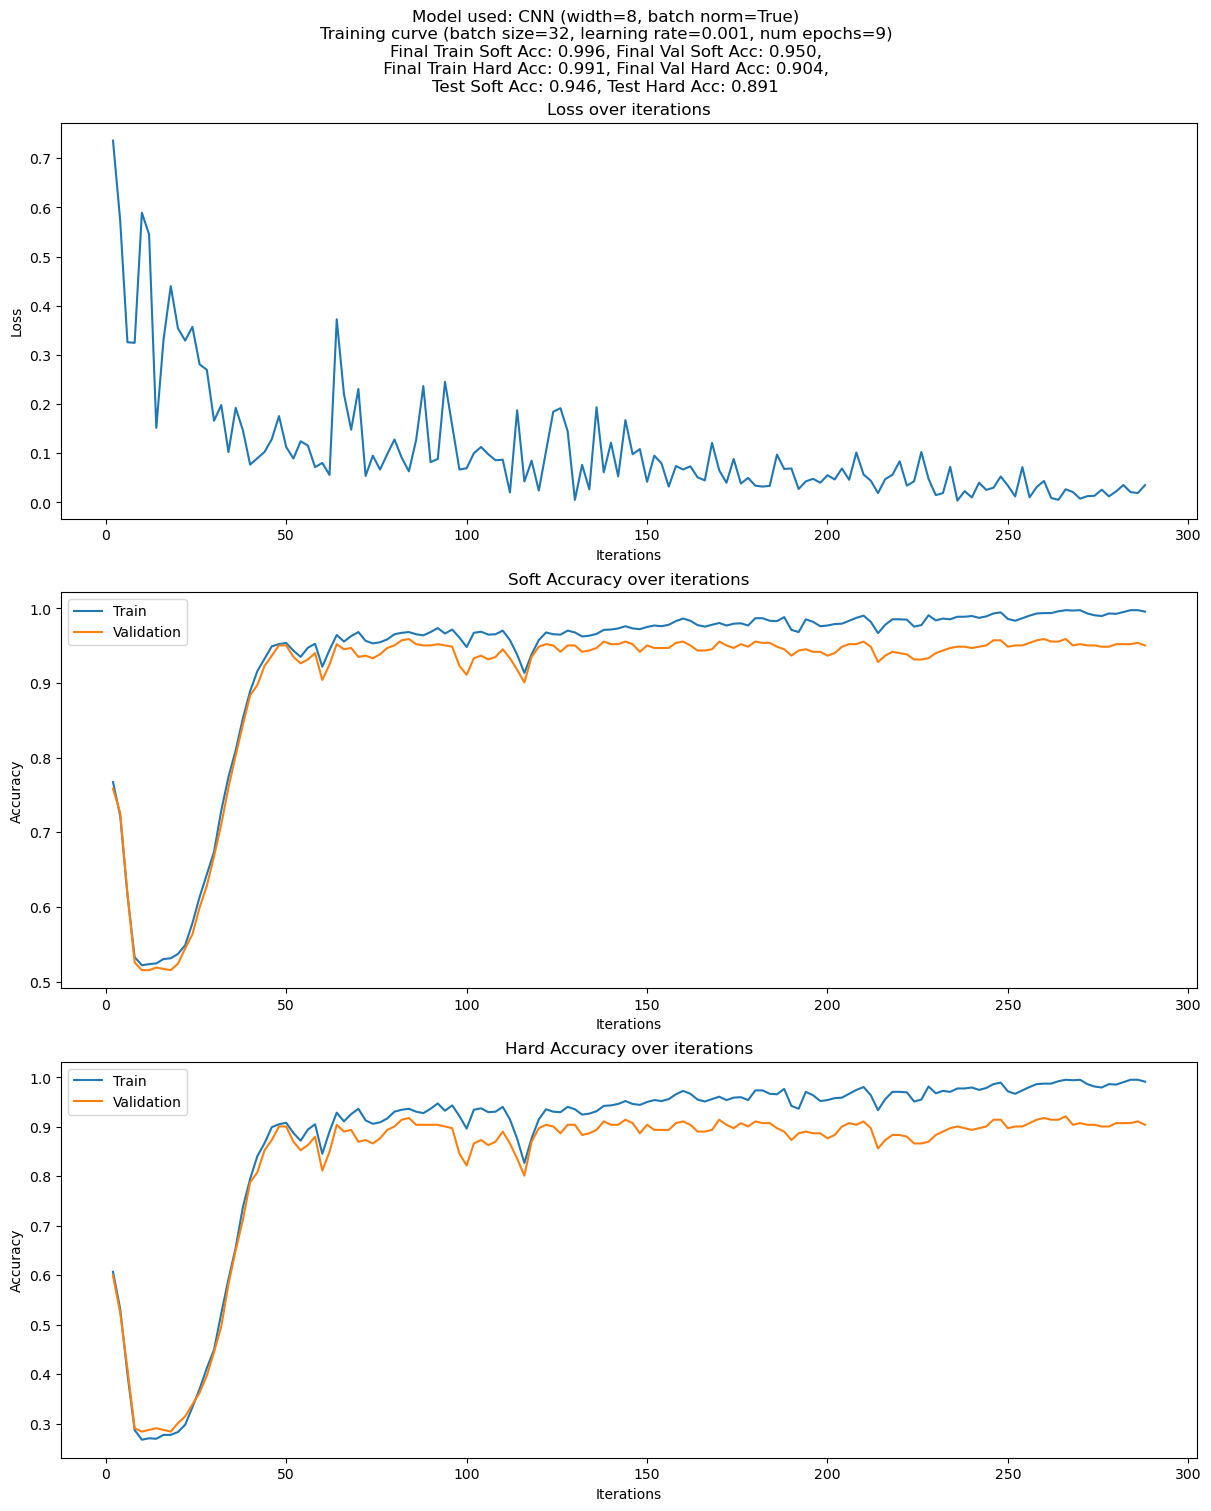

In [ ]:
iters, train_loss, train_soft_acc, val_soft_acc, train_hard_acc, val_hard_acc = results
test_soft_acc = soft_accuracy(model, test_dataset)
test_hard_acc = hard_accuracy(model, test_dataset)

final_train_soft_acc = train_soft_acc[-1]
final_val_soft_acc = val_soft_acc[-1]
final_train_hard_acc = train_hard_acc[-1]
final_val_hard_acc = val_hard_acc[-1]
final_loss = train_loss[-1]

fig, axes = plt.subplots(3, 1, figsize=(12, 15), constrained_layout=True)
title = f"Model used: CNN (width={model.width}, batch norm={model.bn})\n" +\
f"Training curve (batch size={batch_size}, learning rate={learning_rate}, num epochs={num_epochs})\n" +\
f"Final loss: {final_loss:.3f}, Final Train Soft Acc: {final_train_soft_acc:.3f}, Final Val Soft Acc: {final_val_soft_acc:.3f},\n" +\
f" Final Train Hard Acc: {final_train_hard_acc:.3f}, Final Val Hard Acc: {final_val_hard_acc:.3f}, \n" +\
f"Test Soft Acc: {test_soft_acc:.3f}, Test Hard Acc: {test_hard_acc:.3f}"
fig.suptitle(title, fontsize=12)

axes[0].plot(iters[:len(train_loss)], train_loss)
axes[0].set_title("Loss over iterations")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Loss")

axes[1].plot(iters[:len(train_soft_acc)], train_soft_acc)
axes[1].plot(iters[:len(val_soft_acc)], val_soft_acc)
axes[1].set_title("Soft Accuracy over iterations")
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Accuracy")
axes[1].legend(["Train", "Validation"])

axes[2].plot(iters[:len(train_hard_acc)], train_hard_acc)
axes[2].plot(iters[:len(val_hard_acc)], val_hard_acc)
axes[2].set_title("Hard Accuracy over iterations")
axes[2].set_xlabel("Iterations")
axes[2].set_ylabel("Accuracy")
axes[2].legend(["Train", "Validation"])

save_path = DIST/ 'training_curves'/ 'ext_high_mass' /f"cnn_wid={model.width}_bn={model.bn}_v2.png"
if not os.path.exists(save_path):
    plt.savefig(save_path)
    #pass
else:
    print(f"File already exists. Not saving the plot to avoid overwriting.")
plt.show()

In [80]:
weights_path = DIST / 'model_weights' / 'ext_high_mass' / f"cnn_wid={model.width}_bn={model.bn}_v2.pth"
if not os.path.exists(weights_path):
    torch.save(model.state_dict(), weights_path)
else:
    print(f"File already exists. Not saving the model weights to avoid overwriting.")

In [28]:
total_iters = 150
n = total_iters / (len(train_dataset) // batch_size + 1)
n

5.0

## Inference

In [93]:
load_path = DIST / 'model_weights' / 'ext_high_mass' / f"cnn_wid={model.width}_bn={model.bn}.pth"
model = CNN(width=8, bn=True)
model.load_state_dict(torch.load(load_path))

device = torch.device("mps")
model.to(device)

CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

In [94]:
test_soft_acc2 = soft_accuracy(model, test_dataset, threshold=0.8)
test_hard_acc2 = hard_accuracy(model, test_dataset, threshold=0.8)

print(f"Test Soft Accuracy with threshold 0.8: {test_soft_acc2:.3f}")
print(f"Test Hard Accuracy with threshold 0.8: {test_hard_acc2:.3f}")

Test Soft Accuracy with threshold 0.8: 0.952
Test Hard Accuracy with threshold 0.8: 0.905


In [105]:
indices = []

for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    
    if torch.equal(label, torch.tensor([1., 1.])):
        indices.append(i)

print(indices)

[3, 4, 7, 13, 16, 31, 34, 35, 37, 39, 41, 42, 45, 54, 56, 59, 60, 66, 77, 82, 86, 87, 100, 104, 110, 111, 113, 119, 123, 133, 135, 140, 143]


In [107]:
images = []
labels = []

for idx in indices:
    image, label = test_dataset[idx]
    images.append(image)
    labels.append(label)

images = torch.stack(images)   # shape: (N, 3, 256, 256)
labels = torch.stack(labels)   # shape: (N, 2)

In [108]:
images = images.to(device)
labels = labels.to(device)

model.eval()

with torch.no_grad():
    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    correct = (preds == labels).all(dim=1).sum().item()
    total = labels.shape[0]

print(f"Mixed-case hard accuracy: {correct/total:.3f}")

Mixed-case hard accuracy: 0.636


In [122]:
success = torch.where((preds == labels).all(dim=1).float() == 1)
fail = torch.where((preds == labels).all(dim=1).float() == 0)
print("Success indices:", success)
print("Fail indices:", fail)

Success indices: (tensor([ 0,  1,  3,  4,  5,  7,  8,  9, 10, 11, 12, 13, 17, 19, 20, 21, 23, 25,
        28, 31, 32], device='mps:0'),)
Fail indices: (tensor([ 2,  6, 14, 15, 16, 18, 22, 24, 26, 27, 29, 30], device='mps:0'),)


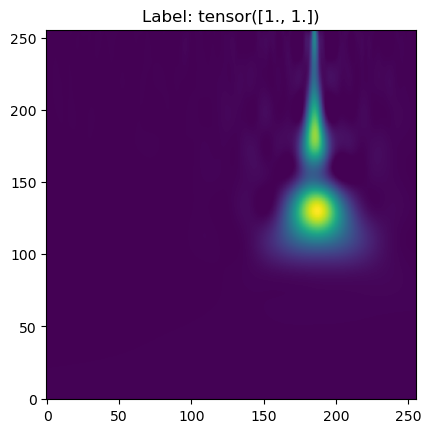

In [129]:
index = 0
image = images[index].cpu()
label = labels[index].cpu()

plt.imshow(image[0], origin="lower")
plt.title(f"Label: {label}")
plt.show()

In [130]:
model.eval()
device = torch.device("mps")

with torch.no_grad():
    image = image.unsqueeze(0).to(device) # add batch dimension and move to device
    output = model(image)
    print('GW probability:', round(torch.sigmoid(output)[0][0].item(), 4))
    print('Glitch probability:', round(torch.sigmoid(output)[0][1].item(), 4)) 

GW probability: 0.9647
Glitch probability: 1.0
